In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("insurance.csv")

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   float64
 1   sex       1338 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   float64
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(4), str(3)
memory usage: 94.5 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1338.000000
mean,39.219147,30.664589,1.095737,13270.422265
std,14.048217,6.100313,1.205571,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.700000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         1
sex         0
bmi         1
children    1
smoker      0
region      0
charges     0
dtype: int64

In [8]:
y=df['charges']
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [9]:
x = df.drop("charges",axis=1)
x

,age,sex,bmi,children,smoker,region
0,19.0,female,27.900,0.0,yes,southwest
1,18.0,male,33.770,1.0,no,southeast
2,28.0,male,33.000,3.0,no,southeast
3,33.0,male,22.705,0.0,no,northwest
4,32.0,male,28.880,0.0,no,northwest
...,...,...,...,...,...,...
1333,50.0,male,30.970,3.0,no,northwest
1334,18.0,female,31.920,0.0,no,northeast
1335,18.0,female,36.850,0.0,no,southeast
1336,21.0,female,25.800,0.0,no,southwest


In [10]:
num_cols=x.select_dtypes(include=["int64","float64"]).columns
cat_cols =x.select_dtypes(include=['object']).columns

C:\Users\acer\AppData\Local\Temp\ipykernel_10680\2226757440.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols =x.select_dtypes(include=['object']).columns


In [11]:
x[num_cols]=x[num_cols].fillna(x[num_cols].median())
x[cat_cols]=x[cat_cols].fillna("missing")

In [12]:
x= pd.get_dummies(x,drop_first=True)

In [13]:
x.shape

(1338, 8)

In [14]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [15]:
y_pred=lr.predict(x_test)

In [16]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)


print("MAE",mae)
print("MsE",mse)
print("RMsE",rmse)
print("R2",r2)


MAE 4283.352944736215
MsE 38358523.77014115
RMsE 6193.425850863248
R2 0.744584304169734


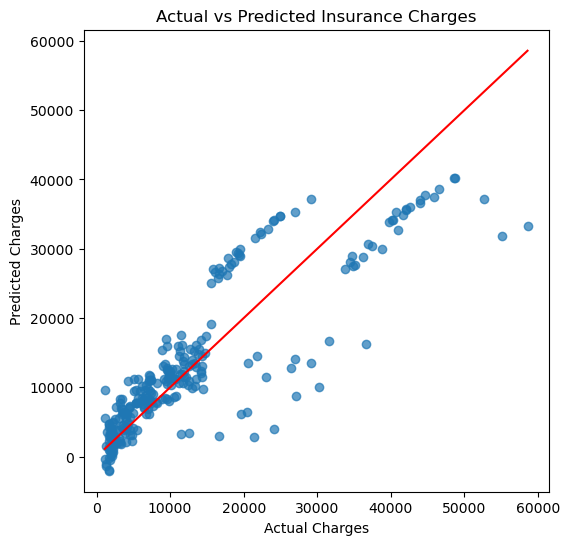

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Insurance Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()


In [18]:
import pandas as pd

result = pd.DataFrame({
    "Actual charge": y_test,
    "Predicted chargre": y_pred
})

result.head(10)

,Actual charge,Predicted chargre
17,2395.17155,1903.941814
1091,11286.53870,11968.885467
273,9617.66245,10482.745752
270,1719.43630,2305.610596
874,8891.13950,8317.550403
790,5662.22500,11151.196943
957,12609.88702,3353.398999
492,2196.47320,1103.708553
1125,14254.60820,12013.460050
794,7209.49180,9470.059027
